In [131]:
import pywt
import numpy as np
import cv2

def image_normalization(src_img):
    """
    白飛び防止のための正規化処理
    cv2.imshowでwavelet変換された画像を表示するときに必要（大きい値を持つ画像の時だけ）
    """
    norm_img = (src_img - np.min(src_img)) / (np.max(src_img) - np.min(src_img))
    return norm_img

def merge_images(cA, cH_V_D):
    """numpy.array を４つ(左上、(右上、左下、右下))連結させる"""
    cH, cV, cD = cH_V_D
    cH = image_normalization(cH) # 外してもok
    cV = image_normalization(cV) # 外してもok
    cD = image_normalization(cD) # 外してもok
    cA = cA[0:cH.shape[0], 0:cV.shape[1]] # 元画像が2の累乗でない場合、端数ができることがあるので、サイズを合わせる。小さい方に合わせます。
    return np.vstack((np.hstack((cA,cH)), np.hstack((cV, cD)))) # 左上、右上、左下、右下、で画素をくっつける

def coeffs_visualization(cof):
    norm_cof0 = cof[0]
    norm_cof0 = image_normalization(norm_cof0) # 外してもok
    merge = norm_cof0
    for i in range(1, len(cof)):
        merge = merge_images(merge, cof[i])  # ４つの画像を合わせていく
    cv2.imshow('', merge)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

def wavelet_transform_for_image(src_image, level, M_WAVELET="db1", mode="sym"):
    data = src_image.astype(np.float64)
    coeffs = pywt.wavedec2(data, M_WAVELET, level=level, mode=mode)
    return coeffs

if __name__ == "__main__":

    filename = '1-3_ROI.png'
    LEVEL = 3

    # 'haar', 'db', 'sym' etc...
    # URL: http://pywavelets.readthedocs.io/en/latest/ref/wavelets.html
    MOTHER_WAVELET = "db1"

    im = cv2.imread(filename)

    print('LEVEL :', LEVEL)
    print('MOTHER_WAVELET', MOTHER_WAVELET)
    print('original image size: ', im.shape)

    """
    各BGRチャネル毎に変換
    cv2.imreadはB,G,Rの順番で画像を吐き出すので注意
    """
    B = 0
    G = 1
    R = 2
    coeffs_B = wavelet_transform_for_image(im[:, :, B], LEVEL, M_WAVELET=MOTHER_WAVELET)
    coeffs_G = wavelet_transform_for_image(im[:, :, G], LEVEL, M_WAVELET=MOTHER_WAVELET)
    coeffs_R = wavelet_transform_for_image(im[:, :, R], LEVEL, M_WAVELET=MOTHER_WAVELET)

    coeffs_visualization(coeffs_B)
    # coeffs_visualization(coeffs_G)
    # coeffs_visualization(coeffs_R)


LEVEL : 3
MOTHER_WAVELET db1
original image size:  (256, 256, 3)


In [139]:
coeffs_B = pywt.dwtn(moving_images11, "db1", level=3, mode="sym")

TypeError: dwtn() got an unexpected keyword argument 'level'

In [133]:
filename = '1-3_ROI.png'
im = cv2.imread(filename)
data = im[:, :, B].astype(np.float64)
coeffs_B = pywt.wavedec2(data, "db1", level=3, mode="sym")

Original data shape: (128, 128, 128)
Reconstructed data shape: (128, 128, 128)


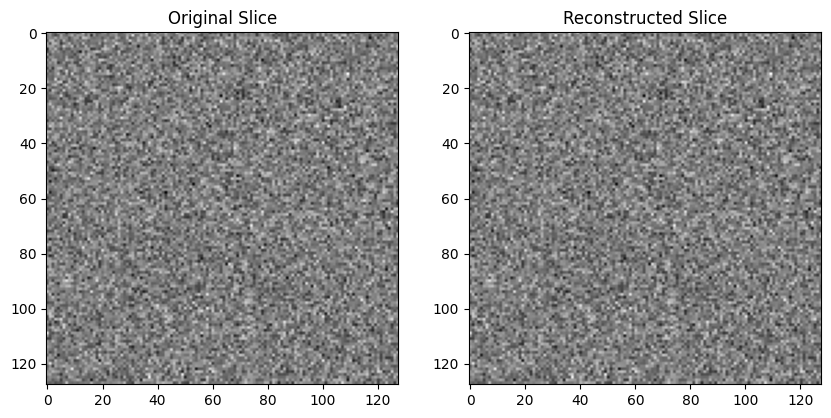

In [140]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# 適当な3次元データの生成（128x128x128のランダムデータ）
data_shape = (128, 128, 128)
random_data = np.random.randn(*data_shape)

# 3次元離散ウェーブレット変換
coeffs = pywt.dwtn(random_data, 'db1', mode='symmetric')

# 3次元逆離散ウェーブレット変換
reconstructed_data = pywt.idwtn(coeffs, 'db1', mode='symmetric')

# 結果の比較
print("Original data shape:", random_data.shape)
print("Reconstructed data shape:", reconstructed_data.shape)

# スライスを表示して比較
slice_index = 64
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Slice')
plt.imshow(random_data[:, :, slice_index], cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Reconstructed Slice')
plt.imshow(reconstructed_data[:, :, slice_index], cmap='gray')
plt.show()


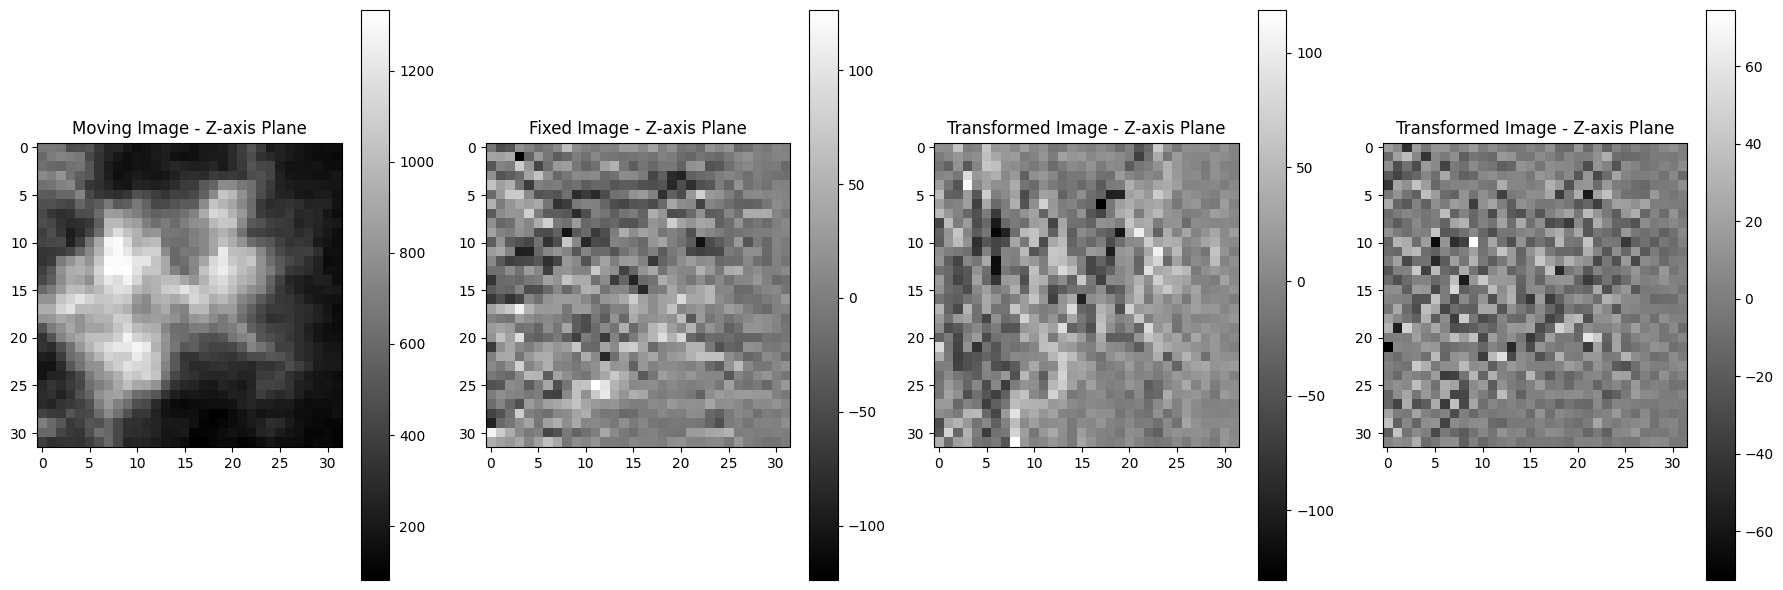

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))  # 図のサイズを大きくする
    
#      moving_imageの表示
plt.subplot(141)
G = coeffs_B[0]
plt.imshow(G, cmap='gray')  # extentで表示範囲を指定
plt.title('Moving Image - Z-axis Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(142)
H = coeffs_B[1][0]
plt.imshow(H, cmap='gray')  # extentで表示範囲を指定
plt.title('Fixed Image - Z-axis Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(143)
I = coeffs_B[1][1]
plt.imshow(I, cmap='gray')  # extentで表示範囲を指定
plt.title('Transformed Image - Z-axis Plane')
plt.colorbar()

# transformed_imageの表示
plt.subplot(144)
I = coeffs_B[1][2]
plt.imshow(I, cmap='gray')  # extentで表示範囲を指定
plt.title('Transformed Image - Z-axis Plane')
plt.colorbar()

plt.tight_layout()
plt.show()

In [129]:
reconstructed_image_32_64 = pywt.idwt2((coeffs_B[0], (coeffs_B[1][0], coeffs_B[1][1], coeffs_B[1][2])), 'db1', mode='symmetric')

TypeError: Invalid shape (256, 64, 2) for image data

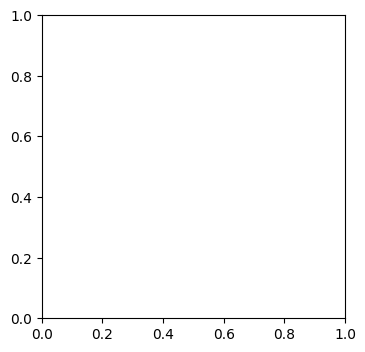

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))  # 図のサイズを大きくする
    
#      moving_imageの表示
plt.subplot(141)
G = reconstructed_image_32_64
plt.imshow(G, cmap='gray')  # extentで表示範囲を指定
plt.title('Moving Image - Z-axis Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(142)
H = coeffs_B[2][0]
plt.imshow(H, cmap='gray')  # extentで表示範囲を指定
plt.title('Fixed Image - Z-axis Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(143)
I = coeffs_B[2][1]
plt.imshow(I, cmap='gray')  # extentで表示範囲を指定
plt.title('Transformed Image - Z-axis Plane')
plt.colorbar()

# transformed_imageの表示
plt.subplot(144)
I = coeffs_B[2][2]
plt.imshow(I, cmap='gray')  # extentで表示範囲を指定
plt.title('Transformed Image - Z-axis Plane')
plt.colorbar()

plt.tight_layout()
plt.show()

In [114]:
reconstructed_image_64_128 = pywt.idwt2((reconstructed_image_32_64, (coeffs_B[2][0], coeffs_B[2][1], coeffs_B[2][2])), 'db1', mode='symmetric')

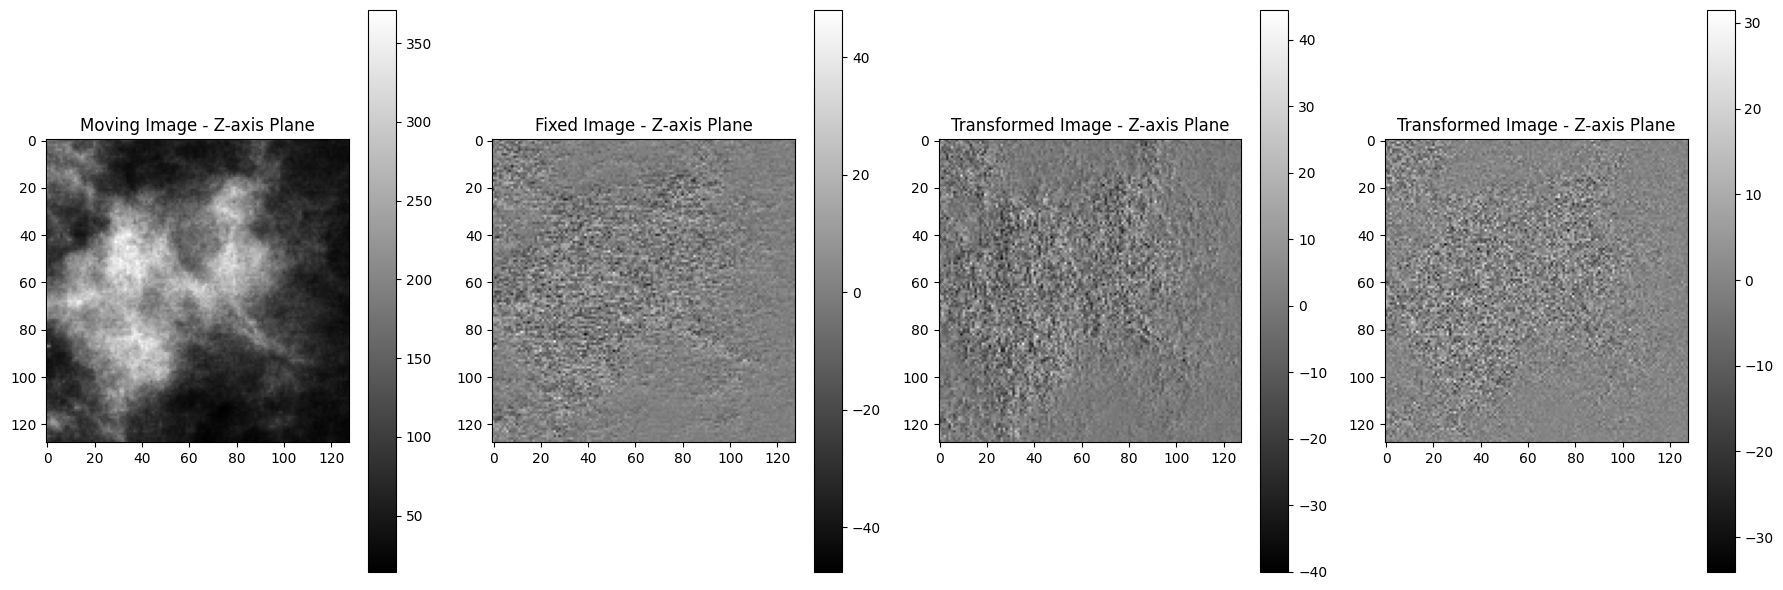

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))  # 図のサイズを大きくする
    
#      moving_imageの表示
plt.subplot(141)
G = reconstructed_image_64_128
plt.imshow(G, cmap='gray')  # extentで表示範囲を指定
plt.title('Moving Image - Z-axis Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(142)
H = coeffs_B[3][0]
plt.imshow(H, cmap='gray')  # extentで表示範囲を指定
plt.title('Fixed Image - Z-axis Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(143)
I = coeffs_B[3][1]
plt.imshow(I, cmap='gray')  # extentで表示範囲を指定
plt.title('Transformed Image - Z-axis Plane')
plt.colorbar()

# transformed_imageの表示
plt.subplot(144)
I = coeffs_B[3][2]
plt.imshow(I, cmap='gray')  # extentで表示範囲を指定
plt.title('Transformed Image - Z-axis Plane')
plt.colorbar()

plt.tight_layout()
plt.show()

In [116]:
reconstructed_image_128_256 = pywt.idwt2((reconstructed_image_64_128, (coeffs_B[3][0], coeffs_B[3][1], coeffs_B[3][2])), 'db1', mode='symmetric')

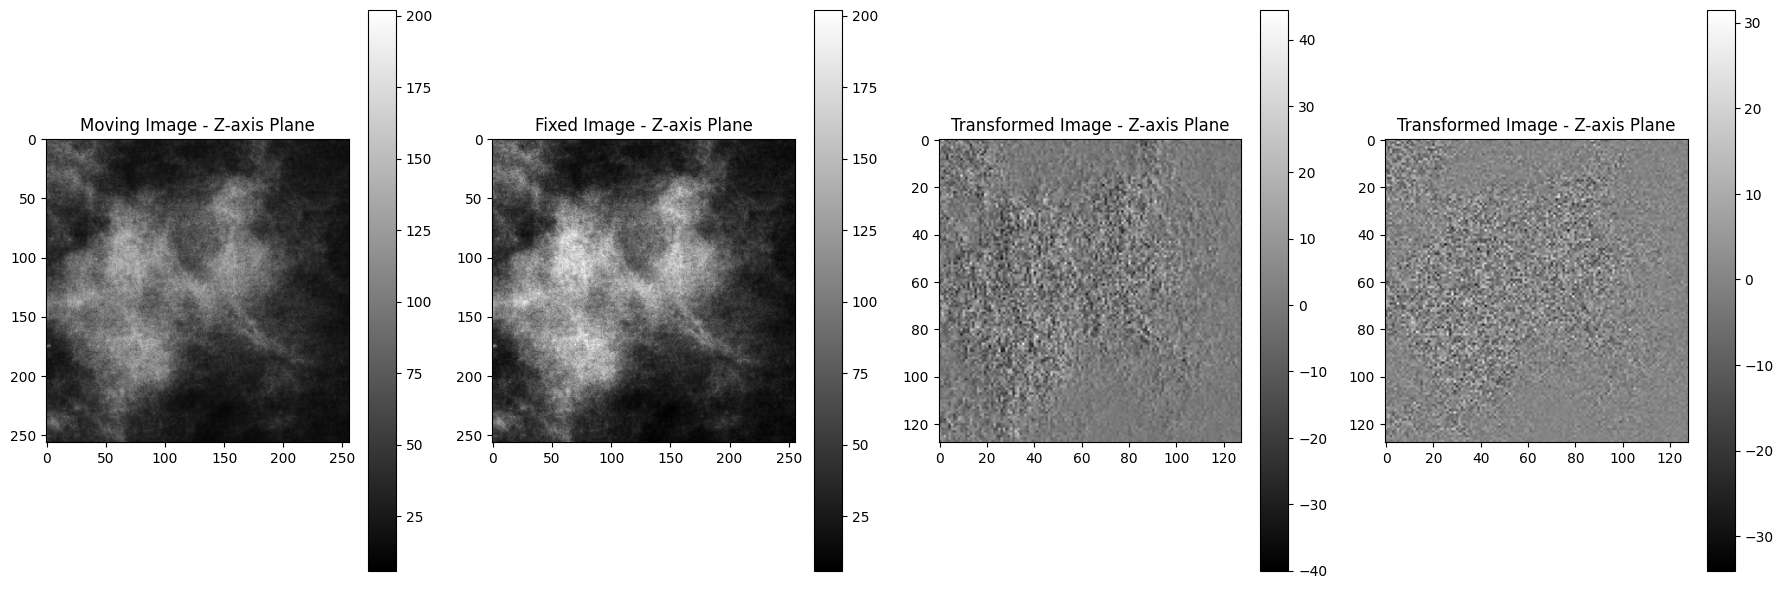

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))  # 図のサイズを大きくする
    
#      moving_imageの表示
plt.subplot(141)
G = im
plt.imshow(G, cmap='gray')  # extentで表示範囲を指定
plt.title('Moving Image - Z-axis Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(142)
H = reconstructed_image_128_256
plt.imshow(H, cmap='gray')  # extentで表示範囲を指定
plt.title('Fixed Image - Z-axis Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(143)
I = coeffs_B[3][1]
plt.imshow(I, cmap='gray')  # extentで表示範囲を指定
plt.title('Transformed Image - Z-axis Plane')
plt.colorbar()

# transformed_imageの表示
plt.subplot(144)
I = coeffs_B[3][2]
plt.imshow(I, cmap='gray')  # extentで表示範囲を指定
plt.title('Transformed Image - Z-axis Plane')
plt.colorbar()

plt.tight_layout()
plt.show()

In [141]:
CT1 = np.load('No6_CT1.npz')['Val']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2.npz')['Val']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

CT1_shape: (1, 128, 128, 128)
CT2_shape: (1, 128, 128, 128)


In [142]:
import torch
x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

torch.Size([2, 1, 128, 128, 128])
torch.Size([2, 1, 128, 128, 128])


Original moving_images11 shape: torch.Size([2, 1, 128, 128, 128])
Original fixed_images11 shape: torch.Size([2, 1, 128, 128, 128])
Reduced moving_images shape: torch.Size([2, 1, 128, 128, 128])
Reduced fixed_images shape: torch.Size([2, 1, 128, 128, 128])


In [220]:
tensor_reshaped = CT2.squeeze()

# サイズを確認
print("After squeeze:", tensor_reshaped.shape)


After squeeze: (128, 128, 128)


Original data shapeｙｋｇｈｋｈｊ: torch.Size([2, 1, 16, 16, 16])
Original data shape: (128, 128, 128)
Reconstructed data shape: (128, 128, 128)


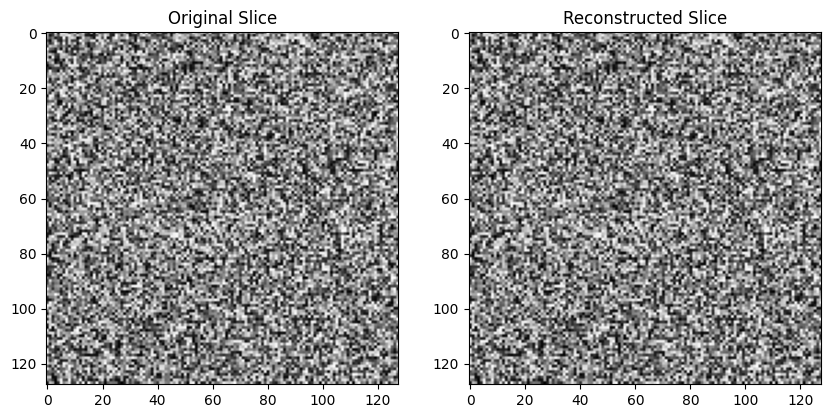

In [225]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
import torch

# 適当な3次元データの生成（128x128x128のランダムデータ）
# data_shape = (128, 128, 128)
# random_data = np.random.randn(*data_shape)

# 3次元多レベル離散ウェーブレット変換
level = 3
coeffs = pywt.wavedecn(tensor_reshaped, 'db1', mode='symmetric', level=level)

coeffs_Moving_16 = coeffs[0]
coeffs_Moving_16_tensor = torch.tensor(coeffs_Moving_16)
coeffs_Moving_16_expanded = coeffs_Moving_16_tensor.unsqueeze(0).unsqueeze(0).expand(2, 1, 16, 16, 16)
print("Original data shapeｙｋｇｈｋｈｊ:", coeffs_Moving_16_expanded.shape)

# 3次元逆離散ウェーブレット変換
reconstructed_data = pywt.waverecn(coeffs, 'db1', mode='symmetric')

# 結果の比較
print("Original data shape:", random_data.shape)
print("Reconstructed data shape:", reconstructed_data.shape)

# スライスを表示して比較
slice_index = 64
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Slice')
plt.imshow(tensor_reshaped[:, :, slice_index], cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Reconstructed Slice')
plt.imshow(reconstructed_data[:, :, slice_index], cmap='gray')
plt.show()


In [189]:
def display_coeffs_structure(coeffs):
    for i, coeff in enumerate(coeffs):
        if i == 0:
            print(f"Level {i} (Approximation coefficients):")
            print(f"  Shape: {coeff.shape}")
        else:
            print(f"Level {i} (Detail coefficients):")
            for key, value in coeff.items():
                print(f"  {key}: Shape: {value.shape}")

# 係数の構造を表示
display_coeffs_structure(coeffs)

Level 0 (Approximation coefficients):
  Shape: (16, 16, 16)
Level 1 (Detail coefficients):
  aad: Shape: (16, 16, 16)
  ada: Shape: (16, 16, 16)
  add: Shape: (16, 16, 16)
  daa: Shape: (16, 16, 16)
  dad: Shape: (16, 16, 16)
  dda: Shape: (16, 16, 16)
  ddd: Shape: (16, 16, 16)
Level 2 (Detail coefficients):
  aad: Shape: (32, 32, 32)
  ada: Shape: (32, 32, 32)
  add: Shape: (32, 32, 32)
  daa: Shape: (32, 32, 32)
  dad: Shape: (32, 32, 32)
  dda: Shape: (32, 32, 32)
  ddd: Shape: (32, 32, 32)
Level 3 (Detail coefficients):
  aad: Shape: (64, 64, 64)
  ada: Shape: (64, 64, 64)
  add: Shape: (64, 64, 64)
  daa: Shape: (64, 64, 64)
  dad: Shape: (64, 64, 64)
  dda: Shape: (64, 64, 64)
  ddd: Shape: (64, 64, 64)


In [ ]:
level_0 = coeffs[0]
level_1_aad = coeffs[1]['aad']
level_1_ada = coeffs[1]['ada']
level_1_add = coeffs[1]['add']
level_1_daa = coeffs[1]['daa']
level_1_dad = coeffs[1]['dad']
level_1_dda = coeffs[1]['dda']
level_1_ddd = coeffs[1]['ddd']

In [200]:
reconstructed_data = pywt.waverecn((level_0, {
    'aad': level_1_aad,
    'ada': level_1_ada,
    'add': level_1_add,
    'daa': level_1_daa,
    'dad': level_1_dad,
    'dda': level_1_dda,
    'ddd': level_1_ddd
}), 'db1', mode='symmetric')


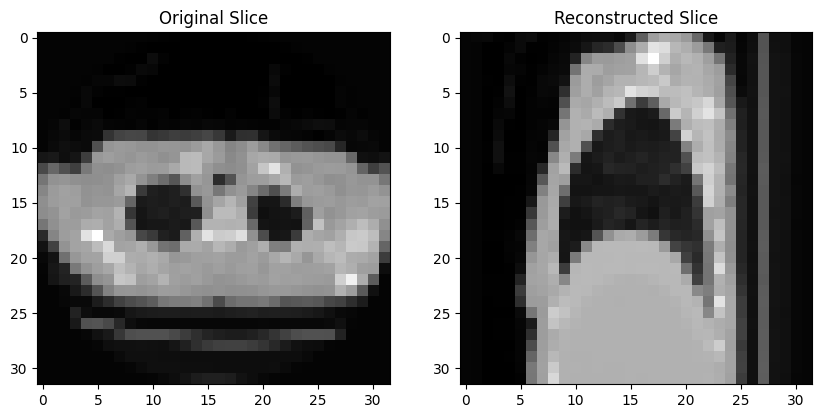

In [204]:
# スライスを表示して比較
slice_index = 8
tensor_reshaped = coeffs[0]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Slice')
plt.imshow(level_1_ddd[6, :, :], cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Reconstructed Slice')
plt.imshow(reconstructed_data[:, :, slice_index], cmap='gray')
plt.show()

In [3]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [4]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [5]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [6]:
x_train = np.load('Train_3D_128_FOV_norm_data.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))
vol_shape = x_train.shape[1:]
print('train vol_shape:', vol_shape)
print('train shape:', x_train.shape)

train vol_shape: (128, 128, 128)
train shape: (57, 128, 128, 128)


In [7]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
inshape = (*x_train.shape[1:], unet_input_features)

# configure unet features 
# nb_features = [
#     [16, 32, 32, 32],
#     [32, 32, 32, 32, 32, 16, 16]
# ]

nb_features = [
    [32, 64, 64, 64],
    [64, 64, 64, 64, 32, 16, 16]
]

# nb_features = [
#     [64, 128, 256, 512],
#     [512, 512, 256, 128, 64, 32, 16]
# ]
model3D = vxm.networks.VxmDense(vol_shape, nb_features, int_steps=0)
model3D.to(device)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[64, 64, 64]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


VxmDense(
  (unet_model_16): Unet(
    (encoder): ModuleList(
      (0): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (1): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (2-3): 2 x ModuleList(
        (0): ConvBlock(
          (main): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
    )
    (decoder): ModuleList(
      (0): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (1-3): 3 x ModuleList(
        (0): ConvBlock(

In [8]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [9]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 128, 128, 128])
Fixed Images Shape: torch.Size([2, 1, 128, 128, 128])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 128, 128, 128])
Zero Gradient Shape: (2, 128, 128, 128, 3)


In [8]:
def wavelet_loss(coeffs_Fixed_32, coeffs_Moving_32, F_1_aad, M_1_aad, F_1_ada, M_1_ada, F_1_add, M_1_add, F_1_daa, M_1_daa, F_1_dad, M_1_dad, F_1_dda, M_1_dda, F_1_ddd, M_1_ddd, F_2_aad, M_2_aad, F_2_ada, M_2_ada, F_2_add, M_2_add, F_2_daa, M_2_daa, F_2_dad, M_2_dad, F_2_dda, M_2_dda, F_2_ddd, M_2_ddd, F_3_aad, M_3_aad, F_3_ada, M_3_ada, F_3_add, M_3_add, F_3_daa, M_3_daa, F_3_dad, M_3_dad, F_3_dda, M_3_dda, F_3_ddd, M_3_ddd):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    R1 = 40
    R2 = 2.5
    R3 = 0.3
    R4 = 0.2
    R11 = 1 
    R12 = 0.25
    
    coeffs_Fixed_32 = torch.tensor(coeffs_Fixed_32, requires_grad=True).to(device)
    coeffs_Moving_32 = torch.tensor(coeffs_Moving_32, requires_grad=True).to(device)

    F_1_aad = torch.tensor(F_1_aad, requires_grad=True).to(device)
    M_1_aad = torch.tensor(M_1_aad, requires_grad=True).to(device)
    F_1_ada = torch.tensor(F_1_ada, requires_grad=True).to(device)
    M_1_ada = torch.tensor(M_1_ada, requires_grad=True).to(device)
    F_1_add = torch.tensor(F_1_add, requires_grad=True).to(device)
    M_1_add = torch.tensor(M_1_add, requires_grad=True).to(device)
    F_1_daa = torch.tensor(F_1_daa, requires_grad=True).to(device)
    M_1_daa = torch.tensor(M_1_daa, requires_grad=True).to(device)
    F_1_dad = torch.tensor(F_1_dad, requires_grad=True).to(device)
    M_1_dad = torch.tensor(M_1_dad, requires_grad=True).to(device)
    F_1_dda = torch.tensor(F_1_dda, requires_grad=True).to(device)
    M_1_dda = torch.tensor(M_1_dda, requires_grad=True).to(device)
    F_1_ddd = torch.tensor(F_1_ddd, requires_grad=True).to(device)
    M_1_ddd = torch.tensor(M_1_ddd, requires_grad=True).to(device)

    F_2_aad = torch.tensor(F_2_aad, requires_grad=True).to(device)
    M_2_aad = torch.tensor(M_2_aad, requires_grad=True).to(device)
    F_2_ada = torch.tensor(F_2_ada, requires_grad=True).to(device)
    M_2_ada = torch.tensor(M_2_ada, requires_grad=True).to(device)
    F_2_add = torch.tensor(F_2_add, requires_grad=True).to(device)
    M_2_add = torch.tensor(M_2_add, requires_grad=True).to(device)
    F_2_daa = torch.tensor(F_2_daa, requires_grad=True).to(device)
    M_2_daa = torch.tensor(M_2_daa, requires_grad=True).to(device)
    F_2_dad = torch.tensor(F_2_dad, requires_grad=True).to(device)
    M_2_dad = torch.tensor(M_2_dad, requires_grad=True).to(device)
    F_2_dda = torch.tensor(F_2_dda, requires_grad=True).to(device)
    M_2_dda = torch.tensor(M_2_dda, requires_grad=True).to(device)
    F_2_ddd = torch.tensor(F_2_ddd, requires_grad=True).to(device)
    M_2_ddd = torch.tensor(M_2_ddd, requires_grad=True).to(device)

    F_3_aad = torch.tensor(F_3_aad, requires_grad=True).to(device)
    M_3_aad = torch.tensor(M_3_aad, requires_grad=True).to(device)
    F_3_ada = torch.tensor(F_3_ada, requires_grad=True).to(device)
    M_3_ada = torch.tensor(M_3_ada, requires_grad=True).to(device)
    F_3_add = torch.tensor(F_3_add, requires_grad=True).to(device)
    M_3_add = torch.tensor(M_3_add, requires_grad=True).to(device)
    F_3_daa = torch.tensor(F_3_daa, requires_grad=True).to(device)
    M_3_daa = torch.tensor(M_3_daa, requires_grad=True).to(device)
    F_3_dad = torch.tensor(F_3_dad, requires_grad=True).to(device)
    M_3_dad = torch.tensor(M_3_dad, requires_grad=True).to(device)
    F_3_dda = torch.tensor(F_3_dda, requires_grad=True).to(device)
    M_3_dda = torch.tensor(M_3_dda, requires_grad=True).to(device)
    F_3_ddd = torch.tensor(F_3_ddd, requires_grad=True).to(device)
    M_3_ddd = torch.tensor(M_3_ddd, requires_grad=True).to(device)

    # Print tensor sizes
#     print("coeffs_Fixed_32:", coeffs_Fixed_32.size())
#     print("coeffs_Moving_32:", coeffs_Moving_32.size())

#     print("F_1_aad:", F_1_aad.size())
#     print("M_1_aad:", M_1_aad.size())
#     print("F_1_ada:", F_1_ada.size())
#     print("M_1_ada:", M_1_ada.size())
#     print("F_1_add:", F_1_add.size())
#     print("M_1_add:", M_1_add.size())
#     print("F_1_daa:", F_1_daa.size())
#     print("M_1_daa:", M_1_daa.size())
#     print("F_1_dad:", F_1_dad.size())
#     print("M_1_dad:", M_1_dad.size())
#     print("F_1_dda:", F_1_dda.size())
#     print("M_1_dda:", M_1_dda.size())
#     print("F_1_ddd:", F_1_ddd.size())
#     print("M_1_ddd:", M_1_ddd.size())

#     print("F_2_aad:", F_2_aad.size())
#     print("M_2_aad:", M_2_aad.size())
#     print("F_2_ada:", F_2_ada.size())
#     print("M_2_ada:", M_2_ada.size())
#     print("F_2_add:", F_2_add.size())
#     print("M_2_add:", M_2_add.size())
#     print("F_2_daa:", F_2_daa.size())
#     print("M_2_daa:", M_2_daa.size())
#     print("F_2_dad:", F_2_dad.size())
#     print("M_2_dad:", M_2_dad.size())
#     print("F_2_dda:", F_2_dda.size())
#     print("M_2_dda:", M_2_dda.size())
#     print("F_2_ddd:", F_2_ddd.size())
#     print("M_2_ddd:", M_2_ddd.size())

#     print("F_3_aad:", F_3_aad.size())
#     print("M_3_aad:", M_3_aad.size())
#     print("F_3_ada:", F_3_ada.size())
#     print("M_3_ada:", M_3_ada.size())
#     print("F_3_add:", F_3_add.size())
#     print("M_3_add:", M_3_add.size())
#     print("F_3_daa:", F_3_daa.size())
#     print("M_3_daa:", M_3_daa.size())
#     print("F_3_dad:", F_3_dad.size())
#     print("M_3_dad:", M_3_dad.size())
#     print("F_3_dda:", F_3_dda.size())
#     print("M_3_dda:", M_3_dda.size())
#     print("F_3_ddd:", F_3_ddd.size())
#     print("M_3_ddd:", M_3_ddd.size())

    # L1 loss
    L1 = torch.sum((coeffs_Fixed_32 - coeffs_Moving_32) ** 2)

    # L2 loss
    L2 = torch.sum(torch.abs((F_1_aad - M_1_aad) + (F_1_ada - M_1_ada) + (F_1_add - M_1_add) + (F_1_daa - M_1_daa) + 
                   (F_1_dad - M_1_dad) + (F_1_dda - M_1_dda) + (F_1_ddd - M_1_ddd)))

    # L3 loss
    L3 = torch.sum(torch.abs((F_2_aad - M_2_aad) + (F_2_ada - M_2_ada) + (F_2_add - M_2_add) + (F_2_daa - M_2_daa) +
                   (F_2_dad - M_2_dad) + (F_2_dda - M_2_dda) + (F_2_ddd - M_2_ddd)))

    # L4 loss
    L4 = torch.sum((R11 * torch.sqrt((F_3_aad - M_3_aad)**2 + (F_3_ada - M_3_ada)**2 + (F_3_add - M_3_add)**2 + (F_3_daa - M_3_daa)**2 +
                           (F_3_dad - M_3_dad)**2 + (F_3_dda - M_3_dda)**2 + (F_3_ddd - M_3_ddd)**2)) + \
         (R12 * torch.abs((F_3_aad - M_3_aad) + (F_3_ada - M_3_ada) + (F_3_add - M_3_add) + (F_3_daa - M_3_daa) +
                          (F_3_dad - M_3_dad) + (F_3_dda - M_3_dda) + (F_3_ddd - M_3_ddd))))
    
#     print("L1:", L1.size())
#     print("L2:", L2.size())
#     print("L3:", L3.size())
#     print("L4:", L4.size())

    total_loss = R1 * L1 + R2 * L2 + R3 * L3 + R4 * L4

    return total_loss, L1, L2, L3, L4


In [9]:
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

In [ ]:
from tqdm.notebook import tqdm
# from visdom import Visdom

# viz = Visdom()

epochs = 10000
loss = []
loss_16 = []
loss_32 = []
loss_64 = []
loss_128 = []
losses = []




# model3D.load_state_dict(torch.load('model_VXM_3D_weights_SGDm.pth', map_location=device)
for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = moving_images.reshape(2 * 1, 128, 128, 128)
    moving_images = moving_images[0]  # 最初の次元だけを選択
    fixed_images = fixed_images.reshape(2 * 1, 128, 128, 128)
    fixed_images = fixed_images[0]  # 最初の次元だけを選択
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # 勾配を初期化
    optimizer.zero_grad()

    # モデルを実行
    moved_level_1, M_1_aad, M_1_ada, M_1_add, M_1_daa, M_1_dad, M_1_dda, M_1_ddd, \
    Fixed_level_1, F_1_aad, F_1_ada, F_1_add, F_1_daa, F_1_dad, F_1_dda, F_1_ddd, \
    coeffs_Moving_32, coeffs_Fixed_32, \
    moved_level_2, M_2_aad, M_2_ada, M_2_add, M_2_daa, M_2_dad, M_2_dda, M_2_ddd, \
    Fixed_level_2, F_2_aad, F_2_ada, F_2_add, F_2_daa, F_2_dad, F_2_dda, F_2_ddd, \
    coeffs_Moving_64, coeffs_Fixed_64, \
    moved_level_3, M_3_aad, M_3_ada, M_3_add, M_3_daa, M_3_dad, M_3_dda, M_3_ddd, \
    Fixed_level_3, F_3_aad, F_3_ada, F_3_add, F_3_daa, F_3_dad, F_3_dda, F_3_ddd, \
    coeffs_Moving_128, coeffs_Fixed_128, \
    moved_128, flow_field_128, flow_field_64, flow_field_32, flow_field_16 = model3D(moving_images, fixed_images)


    # wavelet_loss関数を実行
    total_loss, L1, L2, L3, L4 = wavelet_loss(coeffs_Fixed_32, coeffs_Moving_32, F_1_aad, M_1_aad, F_1_ada, M_1_ada, F_1_add, M_1_add,
                     F_1_daa, M_1_daa, F_1_dad, M_1_dad, F_1_dda, M_1_dda, F_1_ddd, M_1_ddd,
                     F_2_aad, M_2_aad, F_2_ada, M_2_ada, F_2_add, M_2_add, F_2_daa, M_2_daa,
                     F_2_dad, M_2_dad, F_2_dda, M_2_dda, F_2_ddd, M_2_ddd,
                     F_3_aad, M_3_aad, F_3_ada, M_3_ada, F_3_add, M_3_add, F_3_daa, M_3_daa,
                     F_3_dad, M_3_dad, F_3_dda, M_3_dda, F_3_ddd, M_3_ddd)
    print(total_loss)



    # 逆伝播
    total_loss.backward()
    optimizer.step()

    torch.save(model3D.state_dict(), 'model_VXM_3D_weigkjlhfkjhgkhyijgkjhghts_Wavelet.pth')

#     pbar.update(1)
#     pbar.set_postfix({'Loss': loss.item()})
        
    # エポックごとのロスを保存

    
    loss_16.append(L1)
    
    loss_32.append(L2)
    
    loss_64.append(L3)

    loss_128.append(L4)
   
    losses.append(total_loss)    
    
#     viz.line(X=np.array([epoch]), Y=np.array([losses]), win='loss', name='train_loss', update='append')

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss_16: {L1:.4f}, Loss_32: {L2:.4f}, Loss_64: {L3:.4f}, Loss_128: {L4:.4f}, Total Loss: {total_loss:.4f}")
#     print(f"Epoch {epoch+1}/{epochs}, Loss_64: {loss_64:.4f}, Loss_128: {loss_128:.4f}, Total Loss: {loss_all:.4f}")


  0%|          | 0/10000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_19872\726139652.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_19872\726139652.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_19872\2698353580.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coeffs_Fixed_32 = torch.tensor(coeffs_Fixed_32, requires_grad=True).to(devic

tensor(2266295., device='cuda:0', grad_fn=<AddBackward0>)
Epoch 1/10000, Loss_16: 56327.8125, Loss_32: 3010.1162, Loss_64: 6111.8545, Loss_128: 19118.5391, Total Loss: 2266295.0000
tensor(3522208.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 2/10000, Loss_16: 87581.8984, Loss_32: 4187.8945, Loss_64: 8962.9395, Loss_128: 28867.2949, Total Loss: 3522208.2500
tensor(3793360., device='cuda:0', grad_fn=<AddBackward0>)
Epoch 3/10000, Loss_16: 94313.9844, Loss_32: 4785.1504, Loss_64: 9596.7988, Loss_128: 29792.2422, Total Loss: 3793360.0000
tensor(2569107., device='cuda:0', grad_fn=<AddBackward0>)
Epoch 4/10000, Loss_16: 63795.5078, Loss_32: 3642.3774, Loss_64: 8283.7188, Loss_128: 28479.0391, Total Loss: 2569107.0000
tensor(4043170.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 5/10000, Loss_16: 100605.1328, Loss_32: 4420.7690, Loss_64: 8939.9531, Loss_128: 26155.1211, Total Loss: 4043170.2500
tensor(6722650., device='cuda:0', grad_fn=<AddBackward0>)
Epoch 6/10000, Loss_16: 1676

tensor(1918960.1250, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 225/5000, Loss_16: 47621.7539, Loss_32: 3113.6353, Loss_64: 6990.4443, Loss_128: 21043.4766, Total Loss: 1918960.1250
tensor(2351617.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 226/5000, Loss_16: 58344.3867, Loss_32: 4071.7573, Loss_64: 8628.6562, Loss_128: 25369.0312, Total Loss: 2351617.2500
tensor(4900943., device='cuda:0', grad_fn=<AddBackward0>)
Epoch 227/5000, Loss_16: 122033.6875, Loss_32: 4693.5186, Loss_64: 8904.6807, Loss_128: 25949.6797, Total Loss: 4900943.0000
tensor(6043682.5000, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 228/5000, Loss_16: 150524.8750, Loss_32: 5312.8564, Loss_64: 10654.6055, Loss_128: 31045.9688, Total Loss: 6043682.5000
tensor(5019135.5000, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 229/5000, Loss_16: 125003.6484, Loss_32: 4334.1660, Loss_64: 8996.2656, Loss_128: 27274.4453, Total Loss: 5019135.5000
tensor(2778013.7500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 23

Epoch 269/5000, Loss_16: 67391.7734, Loss_32: 3916.1646, Loss_64: 8489.9844, Loss_128: 26272.3281, Total Loss: 2713263.0000
tensor(3767333.7500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 270/5000, Loss_16: 93695.4766, Loss_32: 4332.9805, Loss_64: 9209.6406, Loss_128: 29596.8262, Total Loss: 3767333.7500
tensor(3985953.5000, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 271/5000, Loss_16: 99207.2891, Loss_32: 4123.3809, Loss_64: 8456.7812, Loss_128: 24082.7520, Total Loss: 3985953.5000
tensor(1705929.6250, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 272/5000, Loss_16: 42271.7305, Loss_32: 3313.6255, Loss_64: 7107.3418, Loss_128: 23219.7812, Total Loss: 1705929.6250
tensor(3175365.5000, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 273/5000, Loss_16: 78949.9766, Loss_32: 4077.2122, Loss_64: 7726.7910, Loss_128: 24277.1250, Total Loss: 3175365.5000
tensor(4047478.7500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 274/5000, Loss_16: 100772.0781, Loss_32: 3729.2500, Loss_64: 812

tensor(2972556.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 314/5000, Loss_16: 73842.5234, Loss_32: 4239.8511, Loss_64: 9110.4229, Loss_128: 27611.0254, Total Loss: 2972556.2500
tensor(2197834.7500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 315/5000, Loss_16: 54502.2148, Loss_32: 3819.8628, Loss_64: 8977.0312, Loss_128: 27517.4727, Total Loss: 2197834.7500
tensor(1752965.6250, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 316/5000, Loss_16: 43388.9453, Loss_32: 3680.7510, Loss_64: 8796.1504, Loss_128: 27835.8105, Total Loss: 1752965.6250
tensor(3978002.7500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 317/5000, Loss_16: 98981.6719, Loss_32: 4365.8047, Loss_64: 8845.3740, Loss_128: 25838.8789, Total Loss: 3978002.7500
tensor(2973435.7500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 318/5000, Loss_16: 73923.0781, Loss_32: 3770.2412, Loss_64: 7746.2212, Loss_128: 23816.9648, Total Loss: 2973435.7500
tensor(2985041., device='cuda:0', grad_fn=<AddBackward0>)
Epoch 319/50

Epoch 358/5000, Loss_16: 112137.1875, Loss_32: 4528.3584, Loss_64: 9387.8721, Loss_128: 29790.3770, Total Loss: 4505583.0000
tensor(3578473.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 359/5000, Loss_16: 89034.4531, Loss_32: 3847.7349, Loss_64: 8207.0391, Loss_128: 25070.1406, Total Loss: 3578473.2500
tensor(4459305., device='cuda:0', grad_fn=<AddBackward0>)
Epoch 360/5000, Loss_16: 110972.1797, Loss_32: 4764.9268, Loss_64: 9556.2393, Loss_128: 28192.9238, Total Loss: 4459305.0000
tensor(1820666.6250, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 361/5000, Loss_16: 45142.2227, Loss_32: 3253.1357, Loss_64: 7211.3643, Loss_128: 23407.2344, Total Loss: 1820666.6250
tensor(5957399., device='cuda:0', grad_fn=<AddBackward0>)
Epoch 362/5000, Loss_16: 148403.0938, Loss_32: 4998.3184, Loss_64: 10046.6914, Loss_128: 28825.1133, Total Loss: 5957399.0000
tensor(2507131.5000, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 363/5000, Loss_16: 62208.5234, Loss_32: 4081.7192, Loss_64: 9031.771

tensor(1627905.6250, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 403/5000, Loss_16: 40347.9727, Loss_32: 3057.3071, Loss_64: 6762.0840, Loss_128: 21574.2578, Total Loss: 1627905.6250
tensor(2941037.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 404/5000, Loss_16: 73107.7266, Loss_32: 3839.2578, Loss_64: 7701.6553, Loss_128: 24097.2578, Total Loss: 2941037.2500
tensor(3285503.5000, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 405/5000, Loss_16: 81731.1094, Loss_32: 3541.5776, Loss_64: 7927.0918, Loss_128: 25133.3164, Total Loss: 3285503.5000
tensor(4042744.7500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 406/5000, Loss_16: 100673.5156, Loss_32: 3591.9985, Loss_64: 7511.7603, Loss_128: 22853.6152, Total Loss: 4042744.7500
tensor(2792114.2500, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 407/5000, Loss_16: 69413.4219, Loss_32: 3645.4495, Loss_64: 7299.9941, Loss_128: 21368.6758, Total Loss: 2792114.2500
tensor(3382672., device='cuda:0', grad_fn=<AddBackward0>)
Epoch 408/5

In [10]:
CT1 = np.load('No6_CT1.npz')['Val']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2.npz')['Val']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

CT1_shape: (1, 128, 128, 128)
CT2_shape: (1, 128, 128, 128)


In [11]:
x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

torch.Size([2, 1, 128, 128, 128])
torch.Size([2, 1, 128, 128, 128])


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 学習済みモデルが既にある場合
model3D.load_state_dict(torch.load('model_VXM_3D_weights_Wavelet.pth', map_location=device))


# 検証データを使って予測を行う
model3D.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化
#     moving_images = moving_images
#     fixed_images = fixed_images

    moving_images = fixed_images11
    fixed_images = moving_images11
    moving_images = moving_images.reshape(2 * 1, 128, 128, 128)
    moving_images = moving_images[0]  # 最初の次元だけを選択
    fixed_images = fixed_images.reshape(2 * 1, 128, 128, 128)
    fixed_images = fixed_images[0]  # 最初の次元だけを選択

#     train_batch,_ = next(train_generator)
#     moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
#     fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)  
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    
    moved_level_1, M_1_aad, M_1_ada, M_1_add, M_1_daa, M_1_dad, M_1_dda, M_1_ddd, \
    Fixed_level_1, F_1_aad, F_1_ada, F_1_add, F_1_daa, F_1_dad, F_1_dda, F_1_ddd, \
    coeffs_Moving_32, coeffs_Fixed_32, \
    moved_level_2, M_2_aad, M_2_ada, M_2_add, M_2_daa, M_2_dad, M_2_dda, M_2_ddd, \
    Fixed_level_2, F_2_aad, F_2_ada, F_2_add, F_2_daa, F_2_dad, F_2_dda, F_2_ddd, \
    coeffs_Moving_64, coeffs_Fixed_64, \
    moved_level_3, M_3_aad, M_3_ada, M_3_add, M_3_daa, M_3_dad, M_3_dda, M_3_ddd, \
    Fixed_level_3, F_3_aad, F_3_ada, F_3_add, F_3_daa, F_3_dad, F_3_dda, F_3_ddd, \
    coeffs_Moving_128, coeffs_Fixed_128, \
    moved_128, flow_field_128, flow_field_64, flow_field_32, flow_field_16 = model3D(moving_images, fixed_images)


In [14]:
moving_image = coeffs_Moving_128[0].cpu().numpy()
fixed_image = coeffs_Fixed_128[0].cpu().numpy()
transformed_image = moved_128[0].cpu().numpy()

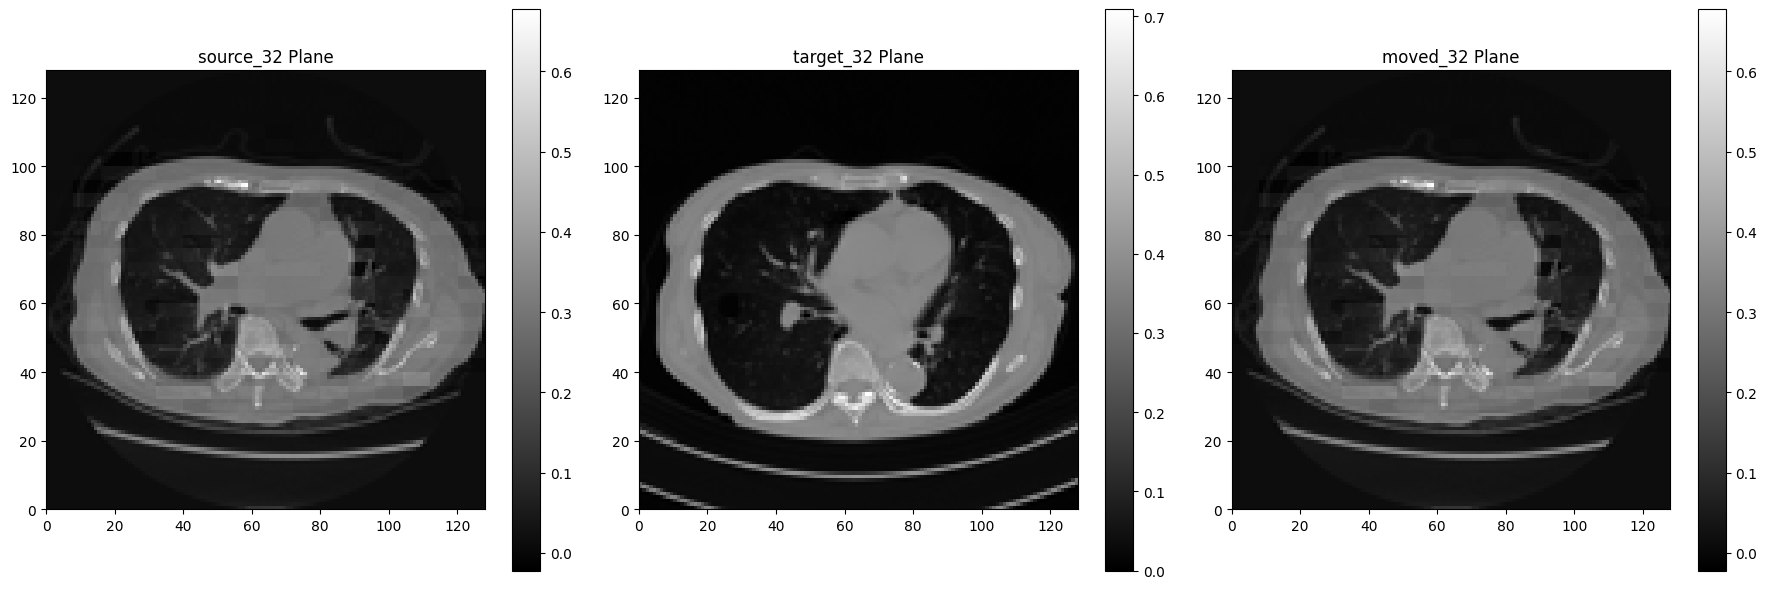

In [15]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする


# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, 64, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('source_32 Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, 64, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('target_32 Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, 64, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moved_32 Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [13]:
print("moving_imagesのデバイス:", moving_images.device)
print("fixed_imagesのデバイス:", fixed_images.device)
print("model3Dのデバイス:", next(model3D.parameters()).device)

# wavelet_loss関数の引数のデバイスを確認
# print("coeffs_Fixed_32のデバイス:", coeffs_Fixed_32.device)
# print("coeffs_Moving_32のデバイス:", coeffs_Moving_32.device)
print("F_1_aadのデバイス:", F_1_aad.device)
print("M_1_aadのデバイス:", M_1_aad.device)
# 必要に応じて、他の引数も確認してください

moving_imagesのデバイス: cuda:0
fixed_imagesのデバイス: cuda:0
model3Dのデバイス: cuda:0


NameError: name 'F_1_aad' is not defined